# Working with Hydro-PE data
## Zarr version using Python + Xarray

<img width="309" height="57" alt="UKCEH and FDRI logos" src="https://github.com/user-attachments/assets/04afdc63-663f-41e4-b29d-9419f78d76c3" />
</br>

**Authors:** [Matt Dalle Piagge](https://mattjbr123.github.io/) and Kit Macleod. With help from: Matt Fry, Mike Brown, Anna Rose Klaptocz, Faiza Samreen, Matt Coole

---

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_zarr_python.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=notebooks/Hydro-PE/hydrope_zarr_python.ipynb)

(CTRL + Click to open in a new tab)

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/fdri-gridded-notebooks/blob/main/README.md#python-and-R-notebook-instructions).

---

## What this notebook does

This notebook explores the **Hydro-PE dataset**. [Hydro-PE](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) is an observations-derived gridded Potential Evaporation dataset for the UK produced by [UKCEH](https://www.ceh.ac.uk/) using the [HadUK-Grid](https://dx.doi.org/10.5285/f02cc6ddd92f45b18b9ab6ab544df7d9) dataset. It contains two variables, Potential Evapotranspiration (PE or PET) and Potential Evapotranspiration with Interception correction (PETI). See the supporting documentation on the [catalogue page](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) for more information on how these are calculated.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored on S3 storage, a storage medium that is becoming increasingly common for large gridded datasets. Datasets on S3 storage are typically stored in the Zarr format. However if you are familiar with working with NetCDF files with Xarray, this will be largely transparent to you with respect to the commands you can use to view and analyse the dataset.

**We will:**
1. Show how to open a dataset stored in Zarr format
2. Show how to extract and plot a time series at a single location
3. Show how to plot a map at a single time step
4. Show how to extract out a catchment area for plotting

**Data store and chunking**

The data is currently publicly available as a trial through JASMIN object storage at the following URLs:
```
https://fdri-o.s3-ext.jc.rl.ac.uk/hydro-pe-spacechunk/hydro-pe_10km_chunks_all.zarr
https://fdri-o.s3-ext.jc.rl.ac.uk/hydro-pe-timechunk/hydro-pe_week_chunks.zarr
```
Each URL links to an identical copy of the dataset, but split up into chunks differently, to enable more performant access for particular types of analysis.

The 'hydro-pe-spacechunk' version is chunked across the spatial dimensions and is more performant for access patterns that extract out timeseries from a single gridpoint or small spatial areas.

The 'hydro-pe-timechunk' version is chunked across the time dimension and is more performant for access patterns that extract out large spatial areas at a single timestep or small number of timesteps.


---

## 0. Setup

### Google Colab

If running on Google Colab, a few extra packages need to be installed for the notebook to run properly:

In [ ]:
# Install if needed (safe to run even if already installed)
%pip install -q zarr netcdf4 cartopy xoak s3fs

You may see a message like "ERROR: pip's dependency resolver does not currently take into account all the packages that are installed...", but that's fine, the packages we need still get installed.

### All platforms

Import the packages we need:

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import xoak
import s3fs

print(f"xarray  version: {xr.__version__}")

xarray  version: 2025.12.0


---
## 1. Open the Zarr store

`xr.open_zarr()` connects to the store over HTTPS without downloading any data yet.  

For publically available data such as this, we do not need any credentials, and instead pass anon=True which means 'access the data as an anonymous user'.

In [3]:
ds_spacechunk = xr.open_zarr(
    "s3://hydro-pe-spacechunk/hydro-pe_10km_chunks_all.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

ds_timechunk = xr.open_zarr(
    "s3://hydro-pe-timechunk/hydro-pe_week_chunks.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

In [4]:
ds_spacechunk

<xarray.Dataset> Size: 214GB
Dimensions:    (time: 20454, y: 1450, x: 900, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 164kB 1969-01-01T12:00:00 ... 2024-12-31...
  * y          (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x          (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB    int32 4B ...
    lat        (y, x) float32 5MB dask.array<chunksize=(10, 10), meta=np.ndarray>
    lon        (y, x) float32 5MB dask.array<chunksize=(10, 10), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 327kB dask.array<chunksize=(20454, 2), meta=np.ndarray>
    x_bnds     (x, bnds) float32 7kB dask.array<chunksize=(10, 2), meta=np.ndarray>
    y_bnds     (y, bnds) float32 12kB dask.array<chunksize=(10, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    pet        (time, y, x) float32 107GB dask.array<chunksize=(20454, 10, 10), meta=np.ndarray>
    peti       (time, y, x) float32 107GB dask.array<chunksize=(20454, 10, 10), meta=np.ndarray>
Attributes: (12/29)
    Conventions:                   CF-1.8, ACDD-1.3
    acknowledgement:               This work has been supported by the Natura...
    cdm_data_type:                 grid
    creator_email:                 enquiries@ceh.ac.uk
    creator_institution:           UK Centre for Ecology & Hydrology (UKCEH)
    geospatial_lat_max:            61.13276672363281
    ...                            ...
    standard_name_url_vocabulary:  NERC Vocabulary Server, https://vocab.nerc...
    standard_name_vocabulary:      CF Standard Name Table v77, http://cfconve...
    summary:                       Gridded potential evapotranspiration calcu...
    time_coverage_resolution:      P1D
    time_coverage_start:           1969-01-01 00:00:00 UTC
    title:                         Potential evapotranspiration derived from ...

In [5]:
ds_timechunk

<xarray.Dataset> Size: 214GB
Dimensions:    (time: 20454, y: 1450, x: 900, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 164kB 1969-01-01T12:00:00 ... 2024-12-31...
  * y          (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x          (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB    int32 4B ...
    lat        (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
    lon        (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 327kB dask.array<chunksize=(7, 2), meta=np.ndarray>
    x_bnds     (x, bnds) float32 7kB dask.array<chunksize=(900, 2), meta=np.ndarray>
    y_bnds     (y, bnds) float32 12kB dask.array<chunksize=(1450, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    pet        (time, y, x) float32 107GB dask.array<chunksize=(7, 1450, 900), meta=np.ndarray>
    peti       (time, y, x) float32 107GB dask.array<chunksize=(7, 1450, 900), meta=np.ndarray>
Attributes: (12/29)
    Conventions:                   CF-1.8, ACDD-1.3
    acknowledgement:               This work has been supported by the Natura...
    cdm_data_type:                 grid
    creator_email:                 enquiries@ceh.ac.uk
    creator_institution:           UK Centre for Ecology & Hydrology (UKCEH)
    geospatial_lat_max:            61.13276672363281
    ...                            ...
    standard_name_url_vocabulary:  NERC Vocabulary Server, https://vocab.nerc...
    standard_name_vocabulary:      CF Standard Name Table v77, http://cfconve...
    summary:                       Gridded potential evapotranspiration calcu...
    time_coverage_resolution:      P1D
    time_coverage_start:           1969-01-01 00:00:00 UTC
    title:                         Potential evapotranspiration derived from ...

Size of dataset in TeraBytes:

In [6]:
ds_spacechunk.nbytes/1E12

0.2135507191

In [7]:
ds_timechunk.nbytes/1E12

0.2135507191

Note that both versions of the dataset are identical sizes, but that the chunksizes shown next to the variables are different.

The variables in the dataset are split into those that describe the coordinates, and those of the main data. We can see the main data variables:  'pet' and 'peti', you can click the page icon at the end of each variable's row to find out a little more about each, and the disks icon next to it to show information about the chunking, noting the different chunking that has been used for each version.

The names in brackets next to the variable names (the second column of information) show you the dimensions that each variable is on. Here, all our data variables are on a 3D grid of time, y and x.

You can see in the Coordinates section that we have other coordinates besides those for the time, y and x dimensions. The lat and lon variables tell you the latitude and longitude conversion for each x,y gridpoint and the 'xxx_bnds' variables tell you the extent/valid range of each datapoint. So for example a gridpoint of (6000,6000) on a grid with a resolution of (1000,1000) would have extents/boundaries of (5500,6500) for both x and y, describing the extent of the gridbox this gridpoint represents. The same concept can be extended to the time-dimension too.

---
## 2. Time series at a single location

Xarray allows you to select out a location using the dataset coordinates, instead of having to worry about indexing.

You can use any of the coordinate variables in the dataset, not just those that the data is actually on. For the HadUK-Grid rainfall dataset it is on the x/y coordinates of the OS National Grid, but you may prefer to select out points based on longitude and latitude, for which a further example is available at the end of the notebook. All FDRI datasets, and in fact all datasets that adhere to the [CF-Conventions](https://cfconventions.org/), will also have longitude and latitude coordinates pre-calculated if the data is not already on a lon/lat grid.  Look at the 'Coordinates' section in the view of the dataset metadata in Section 1 to see what coordinates are available.

**A brief note on chunking:** For this analysis, we will get better performance using the dataset version that is chunked in space. This dataset version uses 10km chunks (and is not chunked in time). Xarray will download only the chunk that contains the data we request.



#### Using x/y coordinates

We can see from the metadata view in Section 1 that the data variables are on an x/y grid. We can use these x/y coordinates to select out a data point to view.

In [8]:
ds_spacechunk['x']

<xarray.DataArray 'x' (x: 900)> Size: 4kB
array([-199500., -198500., -197500., ...,  697500.,  698500.,  699500.],
      dtype=float32)
Coordinates:
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB  int32 4B ...
Attributes:
    axis:           X
    bounds:         x_bnds
    long_name:      easting of British National Grid (BNG) coordinate system
    standard_name:  projection_x_coordinate
    units:          m

In [9]:
ds_spacechunk['y']

<xarray.DataArray 'y' (y: 1450)> Size: 6kB
array([-199500., -198500., -197500., ..., 1247500., 1248500., 1249500.],
      dtype=float32)
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
    crsOSGB  int32 4B ...
Attributes:
    axis:           Y
    bounds:         y_bnds
    long_name:      northing of British National Grid (BNG) coordinate system
    standard_name:  projection_y_coordinate
    units:          m

In [10]:
# Choose a location — e.g. Edinburgh, Scotland
# Adjust to any point within the dataset's extent
target_x = 500000
target_y = 200000

# Choose a time period of interest
start = '2012-06-01'
end = '2012-10-01'

# The variable name — see the 'Data variables' of the view of the dataset metadata in Section 1
var_name = "pet"

# Select the nearest grid cell
# The coordinate names depend on the store — common names: longitude/latitude, lon/lat, x/y
# Note we're using the spacechunk version
timeslice = ds_spacechunk[var_name].sel(time=slice(start, end))
point = timeslice.sel(x=target_x,
                      y=target_y, method='nearest')

# Load the time series into memory, and persist it!
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 1.41 s


In [11]:
ts

<xarray.DataArray 'pet' (time: 123)> Size: 492B
array([3.206578 , 2.571252 , 1.1569023, 1.2083493, 2.3057504, 2.8845565,
       2.6022887, 1.9230748, 1.7777002, 2.5680501, 1.4536403, 1.1354938,
       1.8451536, 2.691414 , 2.7443962, 2.5756528, 2.7403107, 2.3898983,
       2.629189 , 3.3503392, 2.7209156, 2.287533 , 2.566959 , 2.6723962,
       3.238767 , 4.0459347, 4.098895 , 4.148044 , 3.3858807, 2.476608 ,
       2.6231542, 2.8112712, 3.229427 , 3.4120896, 3.6797988, 2.5174468,
       2.8289704, 3.050136 , 2.5610735, 2.3417706, 2.0393767, 2.628517 ,
       2.7119925, 2.0887964, 2.3475077, 2.5790167, 3.44716  , 2.5521698,
       2.3650906, 1.9750423, 2.5034623, 2.9469905, 3.6661348, 4.1095014,
       4.1928167, 3.875589 , 3.1583617, 2.1464753, 1.6737747, 2.115787 ,
       2.5282817, 3.0310855, 2.4190443, 2.8157547, 2.3212695, 2.5365267,
       2.1067665, 2.4704015, 2.67139  , 3.0332196, 3.2220676, 2.9744985,
       3.3619213, 3.17371  , 3.5152843, 2.9407463, 3.1608741, 3.9344895,
       4.056184 , 3.9119492, 3.0656676, 2.4045947, 2.3113754, 2.3521655,
       2.5864666, 2.5208755, 2.1947145, 2.477636 , 2.7992134, 2.1117988,
       0.9864517, 2.0398407, 2.5846498, 2.2479358, 2.984981 , 2.467599 ,
       1.6141073, 2.2598078, 2.6833973, 2.843553 , 3.9609563, 2.6790428,
       1.3219386, 1.3409739, 2.200208 , 1.8302144, 2.5101104, 2.1299376,
       1.8943856, 1.1997488, 1.3411418, 1.7854406, 0.898557 , 1.1116564,
       1.4029357, 1.3489352, 1.5460076, 1.4005691, 1.3606251, 1.3115588,
       0.9202688, 1.8214113, 1.6399281], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 984B 2012-06-01T12:00:00 ... 2012-10-01T12...
    crsOSGB  int32 4B -2147483647
    lat      float32 4B 51.69
    lon      float32 4B -0.5458
    x        float32 4B 5.005e+05
    y        float32 4B 2.005e+05
Attributes:
    cell_methods:       time: mean
    grid_mapping:       crsOSGB
    long_name:          Potential evapotranspiration
    standard_name:      water_potential_evaporation_flux
    standard_name_url:  http://vocab.nerc.ac.uk/standard_name/water_potential...
    units:              kg m-2 d-1

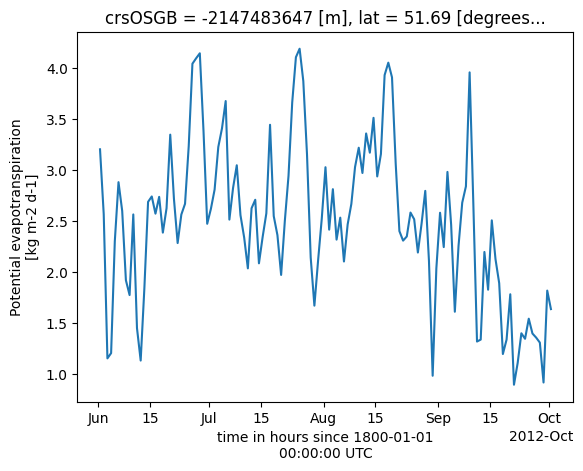

In [12]:
ts.plot()

Or you can customise the plot using matplotlib, the standard python plotting library, but this requires a few more lines of code to setup the plot and tweak the things you might want to:

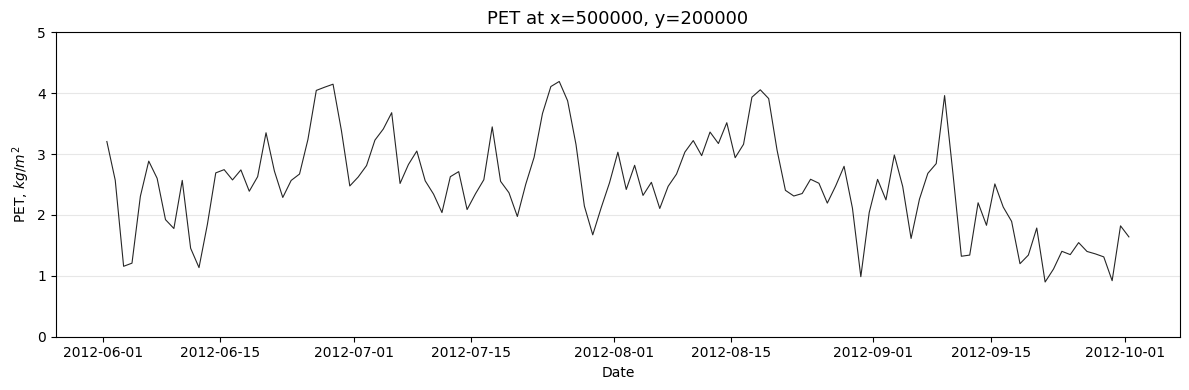

In [13]:
fig, ax = plt.subplots(figsize=(12, 4)) # customize the size of the plot

# plot the data on the axes (ax) we just created using ax.plot(x values, y values, customisations...)
# customize the line colour, width and transparency (alpha)
ax.plot(ts.time, ts.values, color="black", linewidth=0.8, alpha=0.85)

ax.set_title(f"PET at x={target_x}, y={target_y}", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("PET, " + r'$kg/m^2$')
ax.set_ylim([0, 5])
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Map at a single time step

Select one time step and load the full spatial grid. xarray's `.plot()` creates a quick map from any 2-D DataArray. As with selection of x/y coordinates, you can use the time coordinate values to select, instead of having to worry about indexing.

**A brief note on chunking:** For this analysis, we will get better performance using the dataset version that is chunked in time. This dataset version uses daily chunks (and is not chunked in space). Xarray will download only the chunk that contains the data we request.

In [14]:
# Select a time step
# You can use sel(time="YYYY-MM-DD") for date-based selection
t = "2000-01-01"
var_name = 'pet'
daymap = ds_timechunk[var_name].sel(time=t).squeeze() # the squeeze removes the singleton time dimension

with ProgressBar():
    daymap = daymap.compute()

[########################################] | 100% Completed | 2.02 s


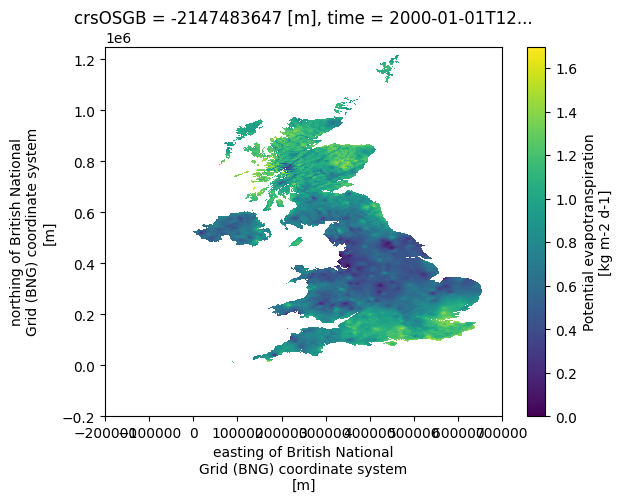

In [15]:
daymap.plot()

But as before we can also customise the plot. For maps, the [cartopy](https://cartopy.readthedocs.io/stable/) library is generally best.

In [16]:
import cartopy.crs as ccrs # the set of map projections cartopy supports
import cartopy as cp # the full cartopy package

Passing the projection 'key-word argument' to the plotting function tells the plotting library to invoke cartopy to draw the plot using a given map projection. Here we are using the 'OSGB' map projection (a cartesian grid, in other words a flat plane approximation that ignores the curvature of the earth) which a lot of UK hydrological data will be on. For any data that is on a 'lon/lat' grid instead of an 'x/y' grid, the ccrs.PlateCarree() projection is a better option.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


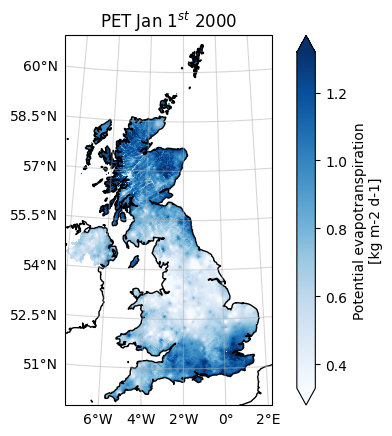

In [17]:
plot1 = daymap.plot.pcolormesh(cmap='Blues', robust=True, subplot_kws=dict(projection=ccrs.OSGB())) # create the initial plot
plt.title(r'PET Jan $1^{st}$ 2000')
plot1.axes.coastlines() # add coastlines
gl = plot1.axes.gridlines(draw_labels=['bottom', 'left'], alpha=0.5) # add gridlines. The alpha parameter is the transparency between 0 and 1.

---
## 4. Catchment extraction

We can also extract out a particular river catchment to look at, instead of the whole UK.

To do this we need the [geopandas](https://geopandas.org/en/stable/getting_started/introduction.html) library, a shapefile to use for the subsetting, and some extra code utilities.

Fetch code utilities:

In [ ]:
!wget https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py

from utils import *

If running on Windows, or some Linux environments, you'll need to use curl instead of wget:

In [ ]:
!curl -o utils.py https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py

from utils import *

Load geopandas

In [19]:
import geopandas as gpd

Read in the shapefile from the cloud (publically available for use):

In [20]:
sfname = 's3://example-data/gb_catchments.zip'
fs_shp = s3fs.S3FileSystem(anon=True, endpoint_url="https://fdri-o.s3-ext.jc.rl.ac.uk")
sfile = gpd.read_file(fs_shp.open(sfname))

sfile

,OBJECTID,ID_STRING,ID,SHAPE_AREA,SHAPE_LEN,geometry
0,227,18010,18010.0,0.0,0.0,"POLYGON ((271449.998 695224.998, 271400 695224..."
1,244,21014,21014.0,0.0,0.0,"POLYGON ((310900.002 628474.999, 311150.002 62..."
2,245,21015,21015.0,0.0,0.0,"POLYGON ((356475.002 638850.002, 356349.999 63..."
3,247,21017,21017.0,0.0,0.0,"POLYGON ((323424.998 613149.998, 323375 613100..."
4,269,22004,22004.0,0.0,0.0,"POLYGON ((421150.002 612925, 421225.001 612850..."
...,...,...,...,...,...,...
1888,174,21003,21003.0,0.0,0.0,"POLYGON ((325775.002 640050, 325775.002 640000..."
1889,187,19021,19021.0,0.0,0.0,"POLYGON ((333800.001 667825.002, 333900.002 66..."
1890,197,20806,20806.0,0.0,0.0,"POLYGON ((363849.998 677374.998, 364024.998 67..."
1891,204,17004,17004.0,0.0,0.0,"POLYGON ((333000 699774.998, 333100.001 699774..."


<details>
<summary>

**Instructions for using your own shapefile:** It is also straightforward to use your own shapefile with this code. Click for instructions.
</summary>

**Colab:** Click the folder icon on the left side-panel, then the upload icon (the leftmost icon above the folder list that appears in the extended side-panel). Select your shapefile (ends in .shp) and it's ancillary files (.sbn, .sbx, .shx, .sbn, .dbf, .cpg etc.). They can then be read in with ```sfile = gpd.open_file('shapefile_name.shp') ```. Note that the files will not be retained when the runtime ends, which is after a few minutes of inactivity ro when you navigate away from the webpage.

**Binder:** Click the folder icon on the left side-panel, then the upload icon (the button second right of the blue plus button). Select your shapefile (ends in .shp) and it's ancillary files (.sbn, .sbx, .shx, .sbn, .dbf, .cpg etc.). They can then be read in with ```sfile = gpd.open_file('shapefile_name.shp') ```. Note that the files will not be retained when your session ends.

**Local machine:** This as simple as running the code ```sfile = gpd.open_file('path/to/shapefile.shp') ```
</details>

With geopandas each shape in the shapefile is represented by a row in the table, and the metadata associated with each shape by the columns. The geometry column contains the vector information that describes the actual shape.

We can use the subsetting script to cut out a piece of our dataset according to one or more shapes in the shapefile.

This is the convenience function I've developed to ease the process. Put a question mark after a given function, to see more information about it:

In [ ]:
catchment_subset_shapefile?

We can use any of the columns to identify which shapes we'd like to use to subset our data. In this case, the only helpful one is the 'ID' column, which refers to the ID of a given catchment in the NRFA database. These can be [explored here](https://nrfa.ceh.ac.uk/data/search).

Catchment ID 39001 is the 'Thames to Kingston' catchment, which is the entire non-tidal Thames basin.

In [21]:
cat39001data = catchment_subset_shapefile(data=daymap, sfname=sfname,
                                          endpoint="https://fdri-o.s3-ext.jc.rl.ac.uk",
                                          IDname='ID_STRING', IDs=['39001'], drop=1)

Found: 39001
Adding mask to xarray


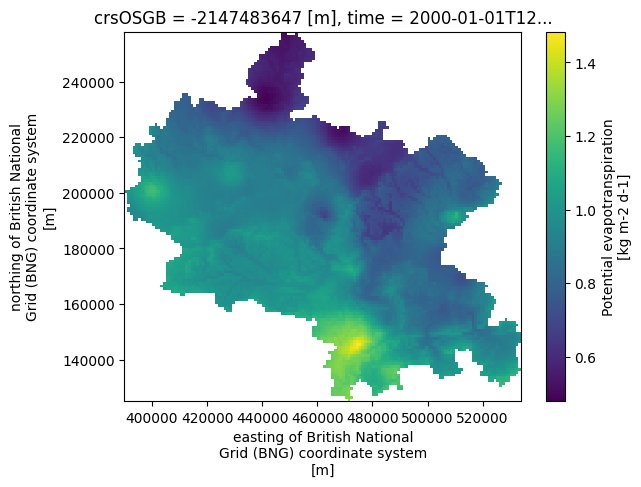

In [22]:
cat39001data.plot()

Or a better plot, where I've chose to highlight the Chess catchment too:

Text(0.5, 1.0, 'PET on 2000-01-01')

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


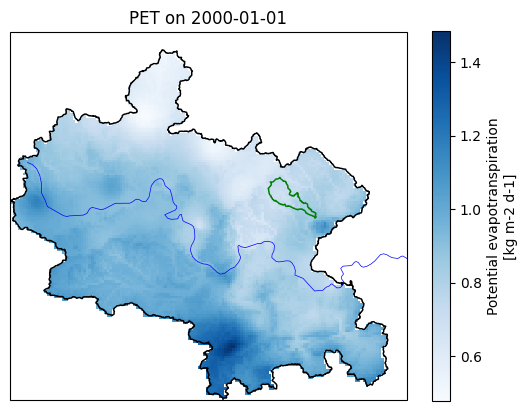

In [23]:
cat39001 = sfile.where(sfile['ID_STRING']=='39001').dropna() # Thames to Kingston
cat39088 = sfile.where(sfile['ID_STRING']=='39088').dropna() # Chess to Rickmansworth

gbax = plt.axes(projection=cp.crs.OSGB()) # create the (geo) axes for the plot
cat39001.plot(ax=gbax, facecolor='None', edgecolor='black', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
cat39088.plot(ax=gbax, facecolor='None', edgecolor='green', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
rivers = cp.feature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m', edgecolor='blue', facecolor='none', lw=0.5) # add in the river thames from a public data source (Natural Earth)
gbax.add_feature(rivers)
cat39001data.plot(ax=gbax, cmap='Blues', zorder=0) # add the data we extracted earlier to the plot
plt.title("PET on 2000-01-01")

---
## Appendix

### Some other commands to try

| Task | Code |
|------|------|
| Select by date | `ds[var].sel(time="2015-01-01")` |
| Select a date range | `ds[var].sel(time=slice("2015-01-01", "2015-01-31"))` |
| Monthly mean | `ds[var].resample(time="1ME").mean()` |
| Spatial mean over GB | `ds[var].mean(dim=["y", "x"])` |
| Save to NetCDF | `ds.to_netcdf("output.nc")` |

where 'ds[var]' can be replaced with whatever xarray DataArray/DataSet you are working with.

### An introduction to lazy-loading and persistence

<details>
  <summary>More details on lazy-loading and persistence when working with Zarr vs NetCDF</summary>
  
The one difference to be aware of is data *persistence* in memory, which needs to be handled explicitly for performant access. Xarray lazy-loads data, which means it doesn't *actually* load the data into memory until it absolutely has to be. So you may run some code that computes the mean of the dataset (e.g. dmean = ds['variable'].mean(dim='time')), but the computation will only actually be carried out when you want to see the result of this calculation, e.g. through a plot or print statement, or saving to disk. This is standard behaviour whether you are loading in NetCDF from a local disk or reading in a remote Zarr datastore. However, in the latter case the data is generally read in parallel with a library called Dask in order to speed up the otherwise slow latency (lag time) when reading data over a HTTP connection. Dask introduces the concept of persistence *in addition to* lazy loading. What this means in practice is that even when xarray has actually loaded the data, the dask layer beneath this *does not persist* the data, meaning that it is not available in-memory for re-use after plotting - or any other analysis - and would have to be retrieved from source again if you wanted to do anything further with the data. This can be very slow and resource-intensive and is best avoided.

For example, for ```dmean = ds['variable'].mean(dim='time'); print(dmean)``` if you run the code once, xarray will trigger the actual computation and loading of the data on the ```print``` statement and Dask will fetch the data and compute everything in parallel as needed. However, if you were to run ```print(dmean)``` *again*, the same thing would happen, and dask would *recompute* the variable ```dmean``` from scratch. The actual data is not stored in the variable dmean, rather the Dask-instructions for computing it.

To manage this (lack of) persistence there's one key extra command you need to be able to use when working with cloud-based data:

```.compute()```

Calling ```.compute()``` on a variable will trigger the loading and computing of the data for that variable and, crucially, will persist that data in memory, meaning you can use it again without having to recompute everything. So for the above example we would want to run ```dmean = ds.['variable'].mean(dim='time').compute()``` to avoid recomputing dmean when we printed or plotted it.

We will see this ```.compute()``` command being used in the examples that follow.

---
</details>


### Further resources

- [Xarray documentation](https://docs.xarray.dev/en/stable/)
- [Xarray "common usage patterns" tutorial](https://tutorial.xarray.dev/intermediate/01-high-level-computation-patterns.html)
- [Dask documentation](https://docs.dask.org/en/stable/index.html)
- [Dask tutorial](https://ncar.github.io/dask-tutorial/notebooks/00-dask-overview.html)
- [FSSpec documentation](https://filesystem-spec.readthedocs.io/en/latest/)
- [Pangeo tutorial gallery](https://gallery.pangeo.io/repos/pangeo-data/pangeo-tutorial-gallery/index.html)
- [Object storage tutorial](https://github.com/NERC-CEH/object_store_tutorial)
- [**2024** Summer School workshop notebook 1](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-4/HJ-SS_Workshop-4.ipynb), focusing on NetCDF
- [**2024** Summer School workshop notebook 2](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-5/HJ-SS_Workshop-5.ipynb), focusing on Zarr

### Using lon/lat coordinates for selection instead of x/y

We can use lon/lat coordinates instead of x/y coordinates to select data too.

In [24]:
ds_timechunk['lat']

<xarray.DataArray 'lat' (y: 1450, x: 900)> Size: 5MB
dask.array<open_dataset-lat, shape=(1450, 900), dtype=float32, chunksize=(1450, 900), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB  int32 4B ...
    lat      (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
    lon      (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north

In [25]:
ds_timechunk['lon']

<xarray.DataArray 'lon' (y: 1450, x: 900)> Size: 5MB
dask.array<open_dataset-lon, shape=(1450, 900), dtype=float32, chunksize=(1450, 900), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB  int32 4B ...
    lat      (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
    lon      (y, x) float32 5MB dask.array<chunksize=(1450, 900), meta=np.ndarray>
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

Note that these coordinates have been lazily loaded and haven't been read in yet, and as such are represented by dask arrays, AKA arrays that have yet to be filled in with actual values.

To view their actual values we can explicitly load them in. As the arrays are small, this isn't a problem for memory. Calling 'load' in this way *persists* the data in memory. I.e. it is retained in memory for future use.

In [26]:
ds_timechunk['lat'].load()
ds_timechunk['lon'].load()

<xarray.DataArray 'lon' (y: 1450, x: 900)> Size: 5MB
array([[-10.012911 ,  -9.99968  ,  -9.986447 , ...,   1.9916273,
          2.0050106,   2.0183938],
       [-10.014291 , -10.001058 ,  -9.9878235, ...,   1.992322 ,
          2.0057075,   2.0190928],
       [-10.015673 , -10.002437 ,  -9.989201 , ...,   1.9930168,
          2.0064049,   2.0197923],
       ...,
       [-13.002928 , -12.984969 , -12.967009 , ...,   3.5051954,
          3.5235994,   3.5420022],
       [-13.005973 , -12.988009 , -12.970043 , ...,   3.5067472,
          3.5251563,   3.5435643],
       [-13.009019 , -12.991051 , -12.973081 , ...,   3.5083003,
          3.5267143,   3.5451276]], dtype=float32)
Coordinates:
  * y        (y) float32 6kB -1.995e+05 -1.985e+05 ... 1.248e+06 1.25e+06
  * x        (x) float32 4kB -1.995e+05 -1.985e+05 ... 6.985e+05 6.995e+05
    crsOSGB  int32 4B -2147483647
    lat      (y, x) float32 5MB 47.82 47.83 47.83 47.83 ... 61.02 61.02 61.01
    lon      (y, x) float32 5MB -10.01 -10.0 -9.986 -9.973 ... 3.508 3.527 3.545
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [27]:
target_lon = -3.19
target_lat = 55.95
var_name = "pet"

points = xr.Dataset(
    {
        "lat": target_lat,
        "lon": target_lon,
    }
)
ds = ds_timechunk.set_xindex(['lat', 'lon'], xr.indexes.NDPointIndex) # set the (spatial) index on the time-chunked version for speed
ds_spacechunk['lat'] = ds_timechunk['lat'] # assign this new index to the space-chunked version and extract from this for speed
ds_spacechunk['lon'] = ds_timechunk['lon']
ds = ds_spacechunk.set_xindex(['lat', 'lon'], xr.indexes.NDPointIndex)
point = ds[var_name].sel(lat=points.lat, lon=points.lon, method='nearest')

In [28]:
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 1.41 s


In [29]:
ts

<xarray.DataArray 'pet' (time: 20454)> Size: 82kB
array([0.        , 0.        , 0.        , ..., 1.5095916 , 0.91134834,
       0.79757804], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 164kB 1969-01-01T12:00:00 ... 2024-12-31T1...
    crsOSGB  int32 4B -2147483647
    x        float32 4B 3.255e+05
    y        float32 4B 6.735e+05
    lat      float32 4B 55.95
    lon      float32 4B -3.193
Attributes:
    cell_methods:       time: mean
    grid_mapping:       crsOSGB
    long_name:          Potential evapotranspiration
    standard_name:      water_potential_evaporation_flux
    standard_name_url:  http://vocab.nerc.ac.uk/standard_name/water_potential...
    units:              kg m-2 d-1

---
**Data citation:** Hydro-PE, UKCEH, https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca